# Library

In [48]:
# Import Essential Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [49]:
df = pd.read_csv('vehicle_emission_dataset.csv')
df.head()

,Vehicle Type,Fuel Type,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Road Type,Traffic Conditions,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,NOx Emissions,PM2.5 Emissions,VOC Emissions,SO2 Emissions,Emission Level
0,Motorcycle,Electric,2.747609,22,291288,49.083255,1.887738,Highway,Moderate,13.880458,52.883905,18.938861,955.411642,179.930088,1.085520,0.011548,0.096207,0.022936,Medium
1,Bus,Electric,5.743714,3,188398,23.460311,3.544147,City,Heavy,19.136947,5.697343,14.716526,1035.763062,250.505219,1.285628,0.187112,0.073321,0.028021,Medium
2,Bus,Hybrid,4.606368,17,281451,115.508350,4.646886,Highway,Free flow,8.123428,3.953116,18.644522,976.207064,404.979103,0.258189,0.132398,0.014744,0.075334,High
3,Truck,Electric,3.913024,4,151321,18.540217,3.581004,Rural,Heavy,35.994893,0.509678,11.951859,966.919462,463.568608,1.040956,0.166325,0.093490,0.025324,High
4,Truck,Hybrid,1.611297,15,91810,109.596566,3.879303,Highway,Moderate,14.793481,52.450884,2.761138,953.229351,79.514604,1.583390,0.078043,0.020396,0.024986,Low


In [50]:
df.shape

(10000, 19)

In [51]:
df.isnull().sum().sort_values(ascending=False)

Vehicle Type          0
Fuel Type             0
Engine Size           0
Age of Vehicle        0
Mileage               0
Speed                 0
Acceleration          0
Road Type             0
Traffic Conditions    0
Temperature           0
Humidity              0
Wind Speed            0
Air Pressure          0
CO2 Emissions         0
NOx Emissions         0
PM2.5 Emissions       0
VOC Emissions         0
SO2 Emissions         0
Emission Level        0
dtype: int64

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Vehicle Type        10000 non-null  object 
 1   Fuel Type           10000 non-null  object 
 2   Engine Size         10000 non-null  float64
 3   Age of Vehicle      10000 non-null  int64  
 4   Mileage             10000 non-null  int64  
 5   Speed               10000 non-null  float64
 6   Acceleration        10000 non-null  float64
 7   Road Type           10000 non-null  object 
 8   Traffic Conditions  10000 non-null  object 
 9   Temperature         10000 non-null  float64
 10  Humidity            10000 non-null  float64
 11  Wind Speed          10000 non-null  float64
 12  Air Pressure        10000 non-null  float64
 13  CO2 Emissions       10000 non-null  float64
 14  NOx Emissions       10000 non-null  float64
 15  PM2.5 Emissions     10000 non-null  float64
 16  VOC E

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numerical_cols = [
    'Engine Size', 'Age of Vehicle', 'Mileage', 'Speed', 'Acceleration', 
    'Temperature', 'Humidity', 'Wind Speed', 'Air Pressure', 
    'CO2 Emissions', 'NOx Emissions', 'PM2.5 Emissions', 
    'VOC Emissions', 'SO2 Emissions'
]

X = df[numerical_cols] 

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

            feature        VIF
8      Air Pressure  43.395980
0       Engine Size   6.055162
13    SO2 Emissions   5.462477
12    VOC Emissions   5.412398
9     CO2 Emissions   5.374653
11  PM2.5 Emissions   4.667628
10    NOx Emissions   4.605806
7        Wind Speed   4.048200
6          Humidity   4.034555
3             Speed   3.976729
4      Acceleration   3.964920
2           Mileage   3.927002
1    Age of Vehicle   3.846613
5       Temperature   2.071215


In [54]:

df_final = df.drop(columns=['Air Pressure'])


numerical_cols_updated = [col for col in numerical_cols if col != 'Air Pressure']


print(f"Number of columns: {df_final.shape[1]}")
print(df_final.columns)

Number of columns: 18
Index(['Vehicle Type', 'Fuel Type', 'Engine Size', 'Age of Vehicle', 'Mileage',
       'Speed', 'Acceleration', 'Road Type', 'Traffic Conditions',
       'Temperature', 'Humidity', 'Wind Speed', 'CO2 Emissions',
       'NOx Emissions', 'PM2.5 Emissions', 'VOC Emissions', 'SO2 Emissions',
       'Emission Level'],
      dtype='object')


In [55]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig1 = px.scatter(df_final, 
                 x='Engine Size', 
                 y='Speed', 
                 color='Emission Level',
                 title='Vehicle Analysis: Engine Size vs Speed',
                 template='plotly_white',
                 hover_data=['Vehicle Type', 'Fuel Type'])

fig1.show()

fig2 = px.scatter(df_final, 
                 x='CO2 Emissions', 
                 y='NOx Emissions', 
                 color='Emission Level',
                 title='Emissions Analysis: CO2 vs NOx',
                 template='plotly_dark',
                 hover_data=['Vehicle Type', 'Fuel Type'])

fig2.show()

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

le = LabelEncoder()
df_final['Vehicle Type'] = le.fit_transform(df_final['Vehicle Type'])
df_final['Fuel Type'] = le.fit_transform(df_final['Fuel Type'])
df_final['Road Type'] = le.fit_transform(df_final['Road Type'])
df_final['Traffic Conditions'] = le.fit_transform(df_final['Traffic Conditions'])
df_final['Emission Level'] = le.fit_transform(df_final['Emission Level'])

X = df_final.drop('Emission Level', axis=1)
y = df_final['Emission Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

train_acc = dt_unpruned.score(X_train, y_train)
test_acc = accuracy_score(y_test, dt_unpruned.predict(X_test))

print(" Unpruned Decision Tree Results:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Tree Depth:        {dt_unpruned.get_depth()}")
print(f"Gap:               {train_acc - test_acc:.4f}")

 Unpruned Decision Tree Results:
Training Accuracy: 1.0000
Testing Accuracy:  1.0000
Tree Depth:        2
Gap:               0.0000


In [57]:

dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)

train_acc_pruned = dt_pruned.score(X_train, y_train)
test_acc_pruned = accuracy_score(y_test, y_pred_pruned)

print(" Pruned Decision Tree (max_depth=3):")
print(f"Training Accuracy: {train_acc_pruned:.4f}")
print(f"Testing Accuracy:  {test_acc_pruned:.4f}")
print(f"Tree Depth:        {dt_pruned.get_depth()}")
print(f"Number of Leaves:  {dt_pruned.get_n_leaves()}")
print(f"Gap:               {train_acc_pruned - test_acc_pruned:.4f}")

 Pruned Decision Tree (max_depth=3):
Training Accuracy: 1.0000
Testing Accuracy:  1.0000
Tree Depth:        2
Number of Leaves:  3
Gap:               0.0000


In [58]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Unpruned', 'Pruned (depth=3)'],
    'Train Acc': [train_acc, train_acc_pruned],
    'Test Acc': [test_acc, test_acc_pruned],
    'Gap': [train_acc - test_acc, train_acc_pruned - test_acc_pruned],
    'Depth': [dt_unpruned.get_depth(), dt_pruned.get_depth()],
    'Leaves': [dt_unpruned.get_n_leaves(), dt_pruned.get_n_leaves()]
})

print(comparison.to_string(index=False))

           Model  Train Acc  Test Acc  Gap  Depth  Leaves
        Unpruned        1.0       1.0  0.0      2       3
Pruned (depth=3)        1.0       1.0  0.0      2       3


In [59]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

fig = make_subplots(rows=1, cols=3, 
                    subplot_titles=("Test Accuracy (Higher is Better)", 
                                    "Overfitting Gap (Lower is Better)", 
                                    "Model Complexity"))

fig.add_trace(
    go.Bar(x=comparison['Model'], y=comparison['Test Acc'], 
           marker_color=['#EF553B', '#00CC96'], name='Accuracy'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=comparison['Model'], y=comparison['Gap'], 
           marker_color=['#EF553B', '#00CC96'], name='Gap'),
    row=1, col=2
)
fig.add_shape(type="line", x0=-0.5, x1=1.5, y0=0.05, y1=0.05,
              line=dict(color="Orange", width=2, dash="dash"),
              row=1, col=2)

fig.add_trace(
    go.Bar(x=comparison['Model'], y=comparison['Depth'], name='Depth', marker_color='#636EFA'),
    row=1, col=3
)
fig.add_trace(
    go.Bar(x=comparison['Model'], y=comparison['Leaves'], name='Leaves', marker_color='#AB63FA'),
    row=1, col=3
)

fig.update_yaxes(range=[0.8, 1.05], row=1, col=1)
fig.update_layout(height=500, title_text="Decision Tree Comparison: Unpruned vs Pruned", showlegend=True)
fig.show()

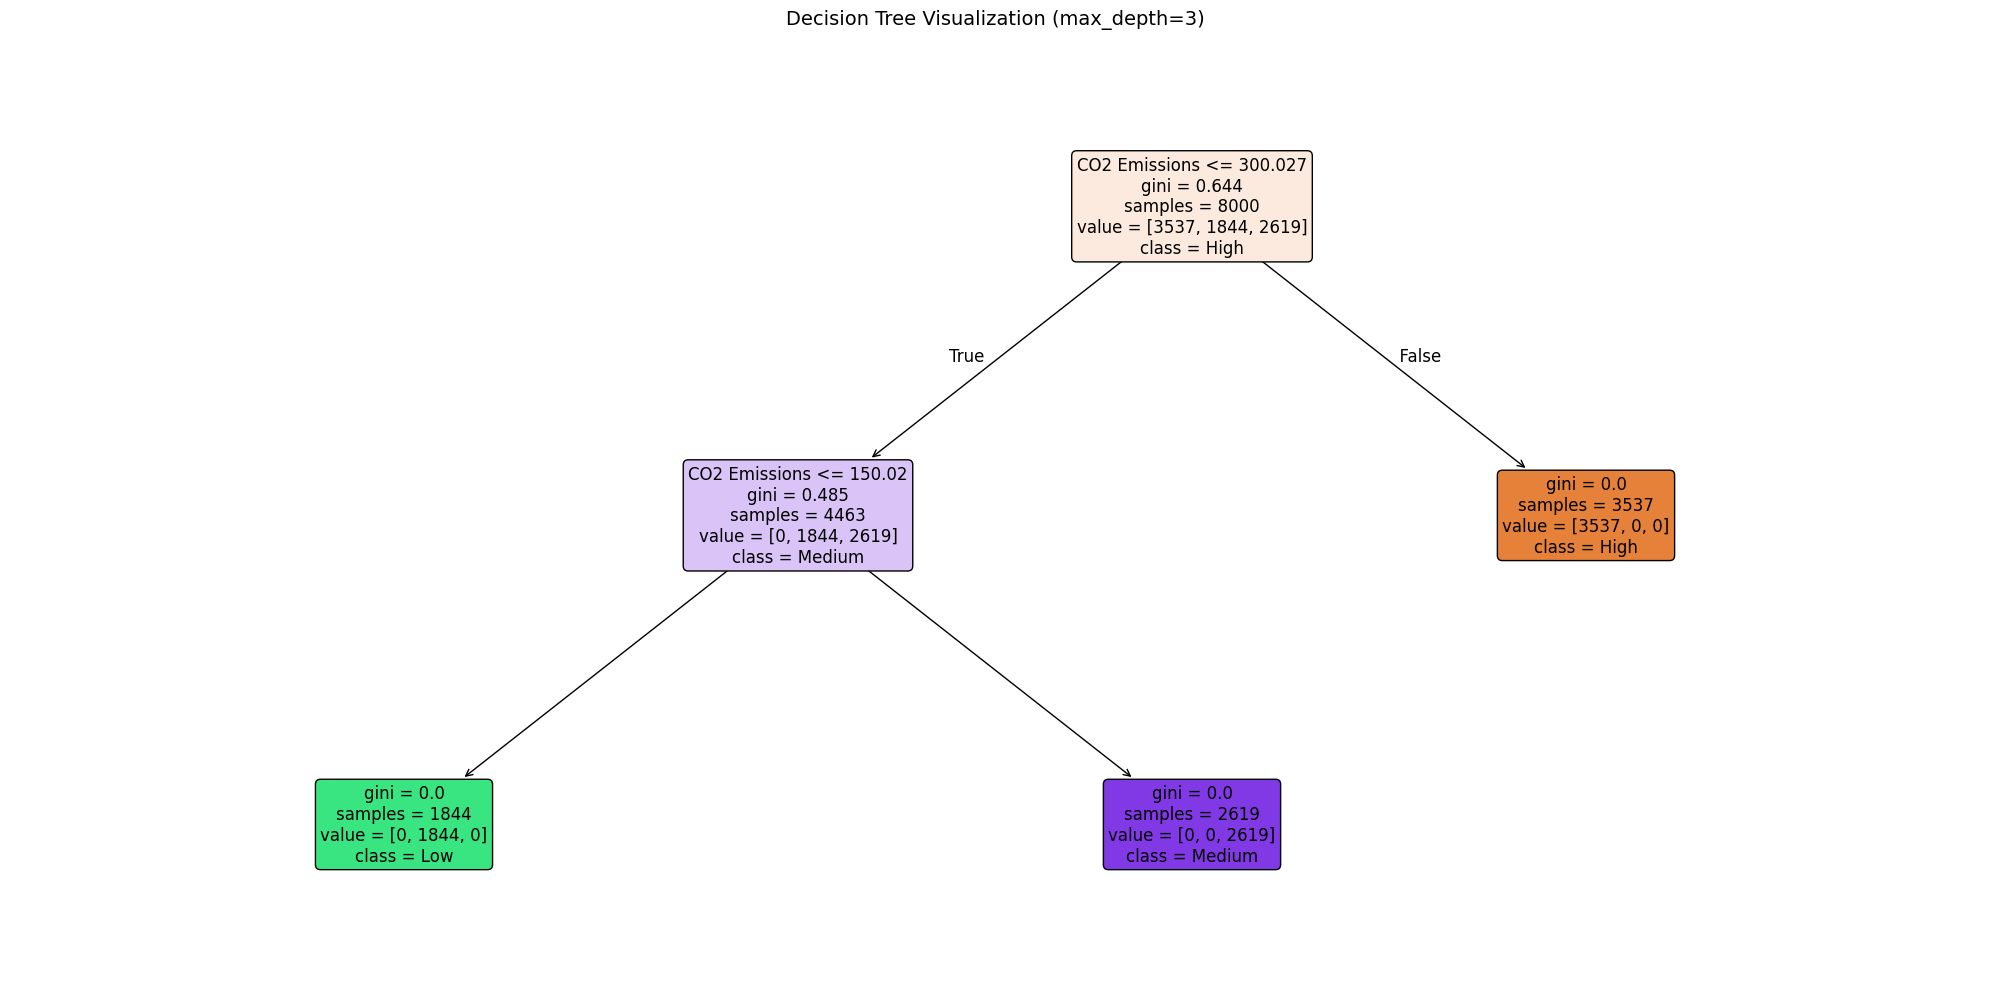

 How to Read the Tree:
  Root: First decision based on most important feature
  Branches: Left is condition True, Right is condition False
  Gini: Impurity measure (0.0 = pure node)
  Samples: Number of vehicles at this stage
  Class: Predicted Emission Level


In [60]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# class_names ko string mein convert karna taake error na aaye
class_names_str = [str(c) for c in le.classes_]

plt.figure(figsize=(20, 10))
plot_tree(dt_pruned, 
          feature_names=list(X.columns),
          class_names=class_names_str,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Decision Tree Visualization (max_depth=3)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print(" How to Read the Tree:")
print("  Root: First decision based on most important feature")
print("  Branches: Left is condition True, Right is condition False")
print("  Gini: Impurity measure (0.0 = pure node)")
print("  Samples: Number of vehicles at this stage")
print("  Class: Predicted Emission Level")

In [61]:
from sklearn.tree import export_text

tree_rules = export_text(dt_pruned, feature_names=list(X.columns))
print(" Decision Tree as Text Rules:")
print("="*70)
print(tree_rules)

 Decision Tree as Text Rules:
|--- CO2 Emissions <= 300.03
|   |--- CO2 Emissions <= 150.02
|   |   |--- class: 1
|   |--- CO2 Emissions >  150.02
|   |   |--- class: 2
|--- CO2 Emissions >  300.03
|   |--- class: 0



In [62]:
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

dt_gini.fit(X_train, y_train)
dt_entropy.fit(X_train, y_train)

gini_acc = dt_gini.score(X_test, y_test)
entropy_acc = dt_entropy.score(X_test, y_test)

print("Splitting Criterion Comparison (max_depth=5):")
print("="*70)
print(f"Gini Impurity:       Accuracy = {gini_acc:.4f}, Depth = {dt_gini.get_depth()}, Leaves = {dt_gini.get_n_leaves()}")
print(f"Entropy (Info Gain): Accuracy = {entropy_acc:.4f}, Depth = {dt_entropy.get_depth()}, Leaves = {dt_entropy.get_n_leaves()}")
print(f"\nDifference: {abs(gini_acc - entropy_acc):.4f}")

Splitting Criterion Comparison (max_depth=5):
Gini Impurity:       Accuracy = 1.0000, Depth = 2, Leaves = 3
Entropy (Info Gain): Accuracy = 1.0000, Depth = 2, Leaves = 3

Difference: 0.0000


In [63]:
depths = range(1, 21)
train_scores_depth = []
test_scores_depth = []
n_leaves = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_scores_depth.append(dt.score(X_train, y_train))
    test_scores_depth.append(dt.score(X_test, y_test))
    n_leaves.append(dt.get_n_leaves())



In [64]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

optimal_depth = depths[np.argmax(test_scores_depth)]

fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=("Tree Depth vs Accuracy", "Tree Depth vs Complexity"))

fig.add_trace(go.Scatter(x=list(depths), y=train_scores_depth, name='Training Accuracy', mode='lines+markers'), row=1, col=1)
fig.add_trace(go.Scatter(x=list(depths), y=test_scores_depth, name='Testing Accuracy', mode='lines+markers'), row=1, col=1)

fig.add_vline(x=optimal_depth, line_dash="dash", line_color="red", 
              annotation_text=f"Optimal depth={optimal_depth}", annotation_position="bottom right", row=1, col=1)

fig.add_trace(go.Scatter(x=list(depths), y=n_leaves, name='Number of Leaves', mode='lines+markers', line_color='green'), row=1, col=2)

fig.update_xaxes(title_text="Max Depth", row=1, col=1)
fig.update_yaxes(title_text="Accuracy", row=1, col=1)
fig.update_xaxes(title_text="Max Depth", row=1, col=2)
fig.update_yaxes(title_text="Number of Leaves", row=1, col=2)

fig.update_layout(height=500, title_text="Decision Tree Performance Analysis", showlegend=True)
fig.show()

print(f"Optimal max_depth: {optimal_depth}")
print(f"Best Test Accuracy: {max(test_scores_depth):.4f}")

Optimal max_depth: 2
Best Test Accuracy: 1.0000


In [65]:
min_samples_values = [2, 5, 10, 20, 50, 100]
min_split_results = []

for min_split in min_samples_values:
    dt = DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
    dt.fit(X_train, y_train)
    
    test_acc = dt.score(X_test, y_test)
    min_split_results.append({
        'min_samples_split': min_split,
        'test_accuracy': test_acc,
        'depth': dt.get_depth(),
        'leaves': dt.get_n_leaves()
    })

min_split_df = pd.DataFrame(min_split_results)

print("📊 Impact of min_samples_split:")
print("="*70)
print(min_split_df.to_string(index=False))

fig = px.line(min_split_df, x='min_samples_split', y='test_accuracy', 
              markers=True, title='Min Samples Split vs Accuracy')
fig.show()

📊 Impact of min_samples_split:
 min_samples_split  test_accuracy  depth  leaves
                 2            1.0      2       3
                 5            1.0      2       3
                10            1.0      2       3
                20            1.0      2       3
                50            1.0      2       3
               100            1.0      2       3


In [66]:
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=("min_samples_split vs Accuracy", "min_samples_split vs Complexity"))

fig.add_trace(
    go.Scatter(x=min_split_df['min_samples_split'], y=min_split_df['test_accuracy'], 
               name='Test Accuracy', mode='lines+markers', marker=dict(size=10)), 
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=min_split_df['min_samples_split'], y=min_split_df['leaves'], 
               name='Number of Leaves', mode='lines+markers', marker=dict(size=10, symbol='square'),
               line_color='green'), 
    row=1, col=2
)

fig.update_xaxes(title_text="min_samples_split", row=1, col=1)
fig.update_yaxes(title_text="Test Accuracy", row=1, col=1)
fig.update_xaxes(title_text="min_samples_split", row=1, col=2)
fig.update_yaxes(title_text="Number of Leaves", row=1, col=2)

fig.update_layout(height=500, title_text="Impact of min_samples_split on Decision Tree", showlegend=True)
fig.show()

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

print("Starting Grid Search...")

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Grid Search Complete")
print("Best Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
    
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Starting Grid Search...
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Grid Search Complete
Best Hyperparameters:
  criterion: gini
  max_depth: 3
  min_samples_leaf: 1
  min_samples_split: 2
Best Cross-Validation Accuracy: 1.0000


In [68]:
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best, average='weighted')

print(" Best Model Performance on Test Set:")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"F1 Score: {best_f1:.4f}")
print(f"Tree Depth: {best_dt.get_depth()}")
print(f"Number of Leaves: {best_dt.get_n_leaves()}")

 Best Model Performance on Test Set:
Accuracy: 1.0000
F1 Score: 1.0000
Tree Depth: 2
Number of Leaves: 3


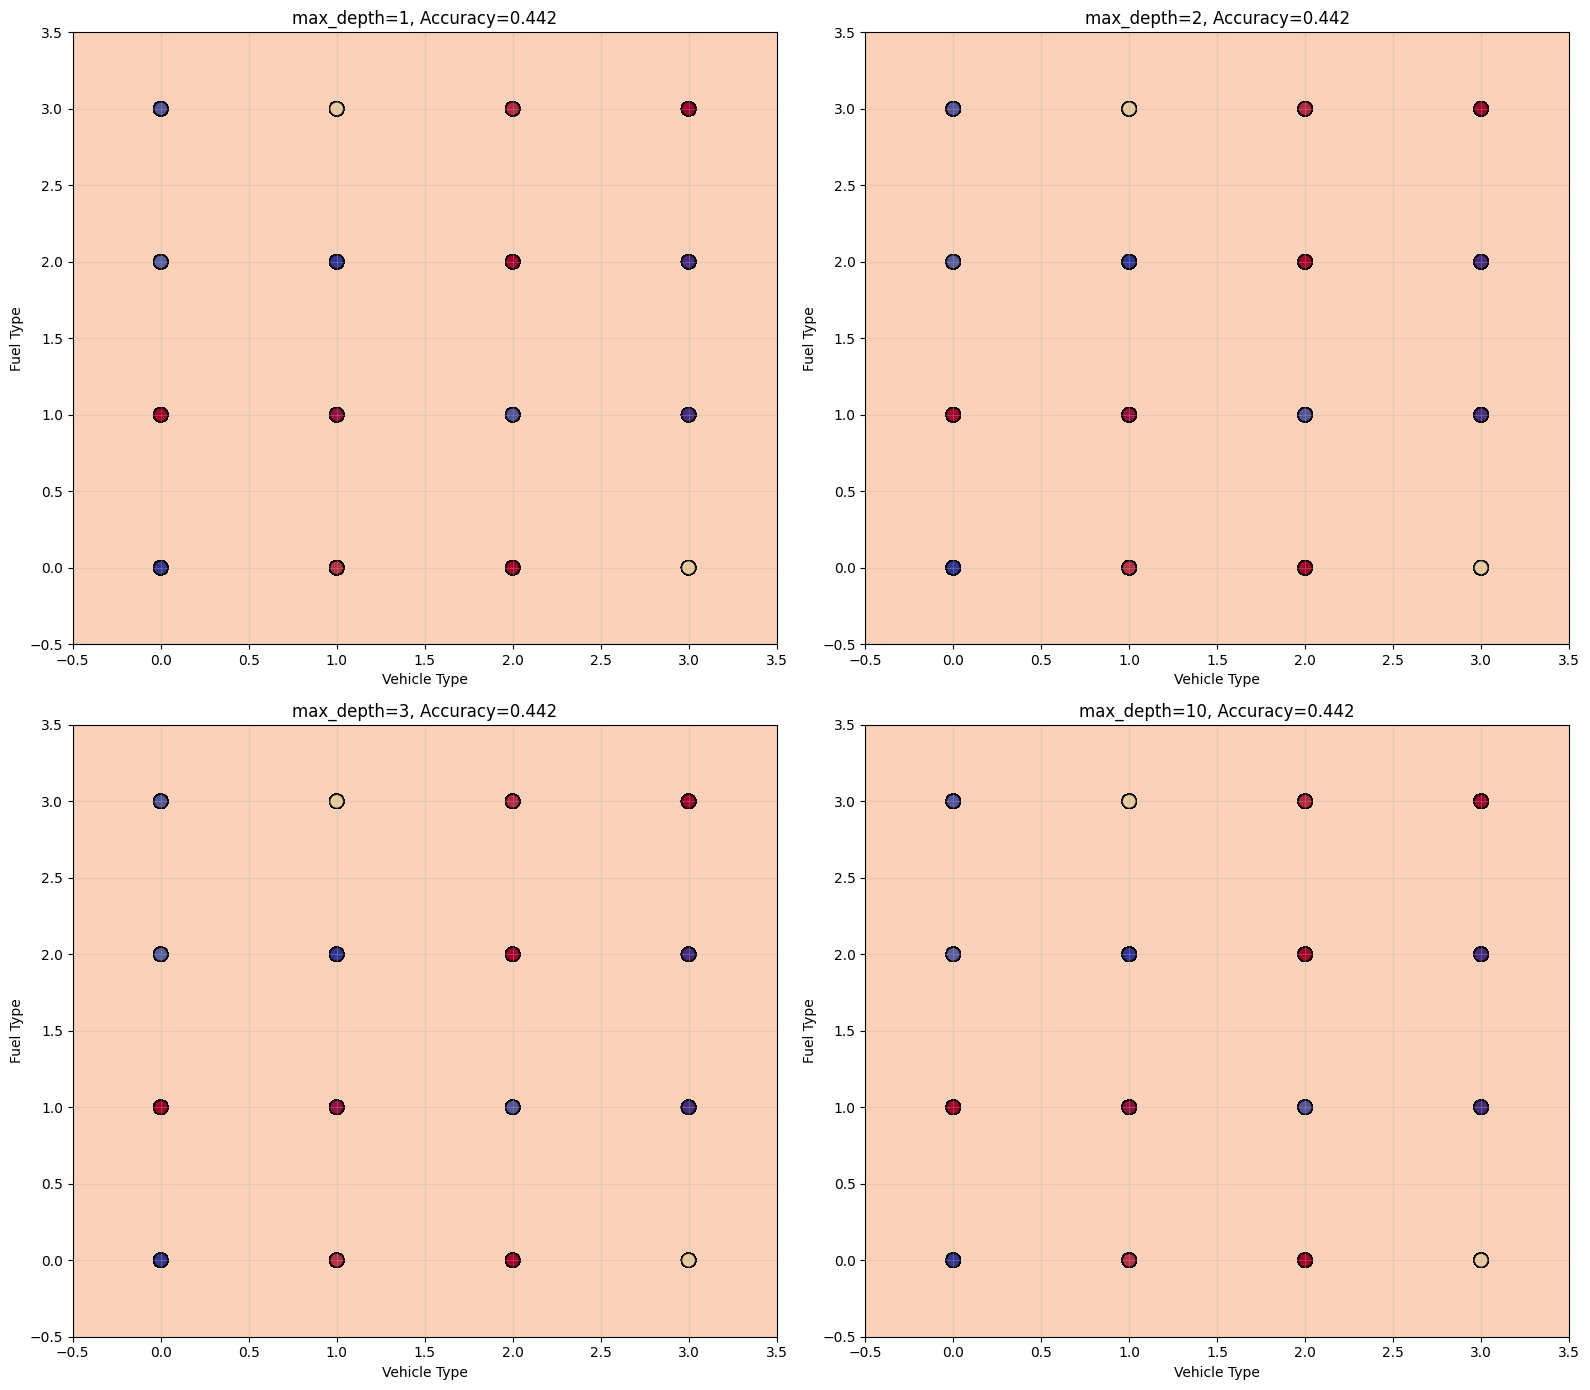

Key Observation:
Depth 1: Simple splits (underfitting)
Depth 2-3: Good balance
Depth 10: Complex rectangles (overfitting)
Decision boundaries are always axis-aligned (rectangular)


In [69]:
feature_1 = X.columns[0] 
feature_2 = X.columns[1]

X_train_2d = X_train[[feature_1, feature_2]].values
X_test_2d = X_test[[feature_1, feature_2]].values

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
depths = [1, 2, 3, 10]

for idx, depth in enumerate(depths):
    ax = axes[idx // 2, idx % 2]
    
    dt_2d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_2d.fit(X_train_2d, y_train)
    
    x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
    y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = dt_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
               c=y_test, cmap='RdYlBu',
               edgecolors='black', s=100, alpha=0.8)
    
    accuracy_2d = dt_2d.score(X_test_2d, y_test)
    ax.set_xlabel(feature_1)
    ax.set_ylabel(feature_2)
    ax.set_title(f'max_depth={depth}, Accuracy={accuracy_2d:.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observation:")
print("Depth 1: Simple splits (underfitting)")
print("Depth 2-3: Good balance")
print("Depth 10: Complex rectangles (overfitting)")
print("Decision boundaries are always axis-aligned (rectangular)")

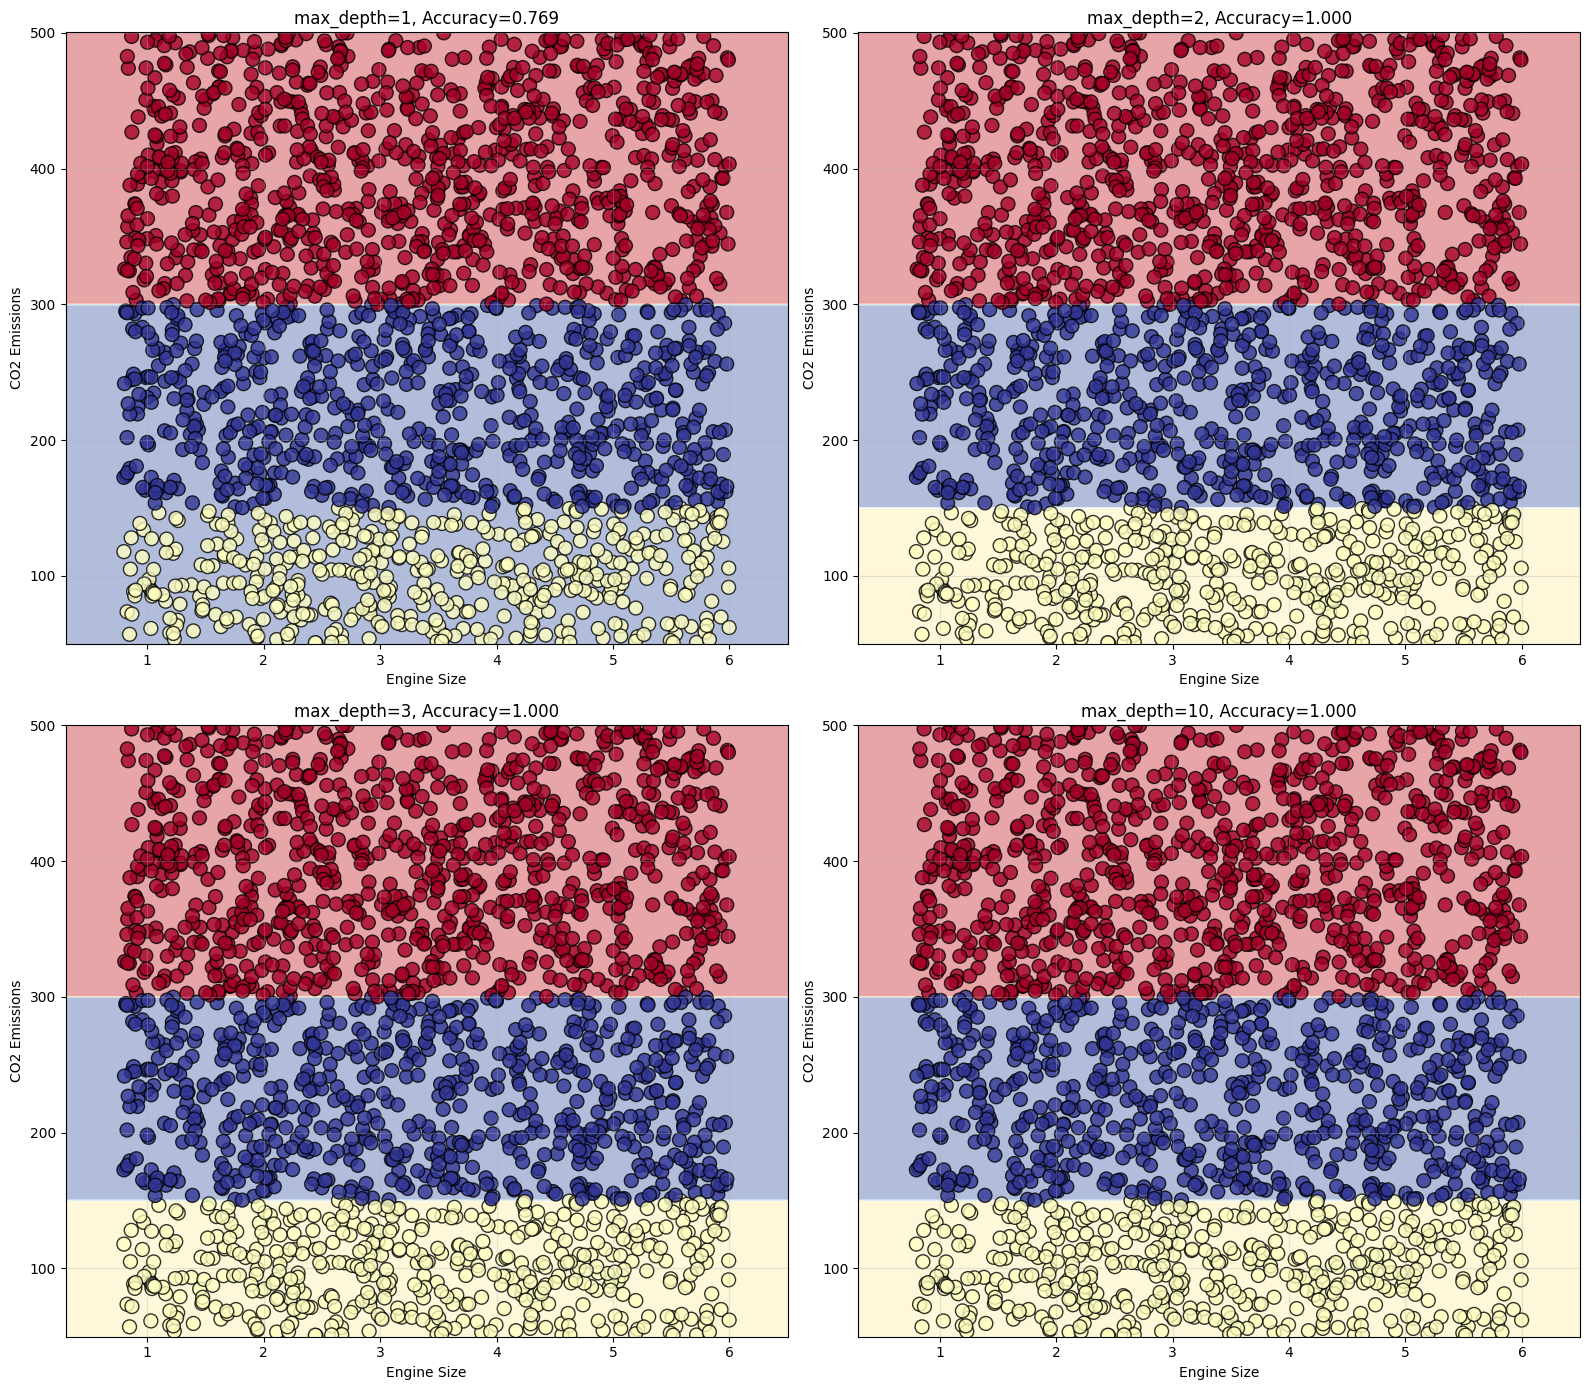

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier


feature_1 = 'Engine Size'
feature_2 = 'CO2 Emissions' 

X_train_2d = X_train[[feature_1, feature_2]].values
X_test_2d = X_test[[feature_1, feature_2]].values

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
depths = [1, 2, 3, 10]

for idx, depth in enumerate(depths):
    ax = axes[idx // 2, idx % 2]
    
    dt_2d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_2d.fit(X_train_2d, y_train)
    
    x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
    y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = dt_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
               c=y_test, cmap='RdYlBu',
               edgecolors='black', s=100, alpha=0.8)
    
    accuracy_2d = dt_2d.score(X_test_2d, y_test)
    ax.set_xlabel(feature_1)
    ax.set_ylabel(feature_2)
    ax.set_title(f'max_depth={depth}, Accuracy={accuracy_2d:.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [71]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Top 15):")
print("="*70)
print(feature_importance.head(15).to_string(index=False))

Feature Importance (Top 15):
           Feature  Importance
     CO2 Emissions         1.0
      Vehicle Type         0.0
         Fuel Type         0.0
    Age of Vehicle         0.0
       Engine Size         0.0
             Speed         0.0
      Acceleration         0.0
         Road Type         0.0
           Mileage         0.0
Traffic Conditions         0.0
       Temperature         0.0
          Humidity         0.0
        Wind Speed         0.0
     NOx Emissions         0.0
   PM2.5 Emissions         0.0


In [72]:
import plotly.express as px

top_features = feature_importance.head(15).sort_values('Importance', ascending=True)

fig = px.bar(top_features, 
             x='Importance', 
             y='Feature', 
             orientation='h',
             title='Top 15 Most Important Features',
             labels={'Importance': 'Gini Importance', 'Feature': 'Vehicle Features'},
             color='Importance',
             color_continuous_scale='Blues')

fig.update_layout(showlegend=False, height=600)
fig.show()

print("Feature Importance Interpretation:")
print(f"Total Features Used: {len(feature_importance[feature_importance['Importance'] > 0])}")
print(f"Top Contributor: {top_features.iloc[-1]['Feature']}")

Feature Importance Interpretation:
Total Features Used: 1
Top Contributor: CO2 Emissions


In [73]:
n_used_features = np.sum(dt_2d.feature_importances_ > 0)

print(f"\n Feature Usage Summary:")
# Aapne sirf 2 features use kiye hain loop mein: Engine Size aur CO2 Emissions
print(f"Total features provided to model: {X_train_2d.shape[1]}") 
print(f"Features actually used:          {n_used_features}")
print(f"Features ignored:                {X_train_2d.shape[1] - n_used_features}")

# Agar aapko dekhna hai kaunsa feature kitna important hai:
print("\n Feature Importances Details:")
features = [feature_1, feature_2]
for name, importance in zip(features, dt_2d.feature_importances_):
    print(f"{name}: {importance:.4f}")


 Feature Usage Summary:
Total features provided to model: 2
Features actually used:          1
Features ignored:                1

 Feature Importances Details:
Engine Size: 0.0000
CO2 Emissions: 1.0000


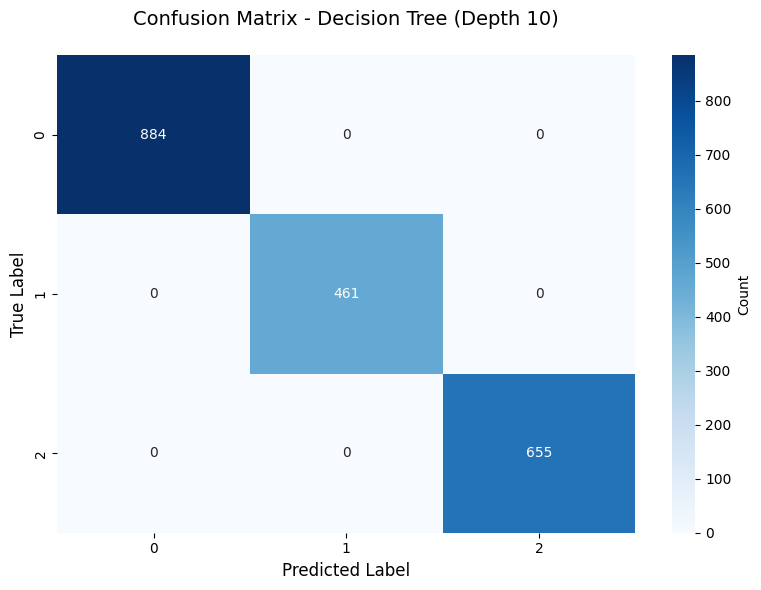

In [74]:
y_pred = dt_2d.predict(X_test_2d)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
labels = np.unique(y_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar_kws={'label': 'Count'})

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - Decision Tree (Depth {depth})\n', fontsize=14)
plt.tight_layout()
plt.show()

In [75]:
labels = [str(l) for l in np.unique(y_test)]

print("\n Detailed Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred, target_names=labels))


 Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       884
           1       1.00      1.00      1.00       461
           2       1.00      1.00      1.00       655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



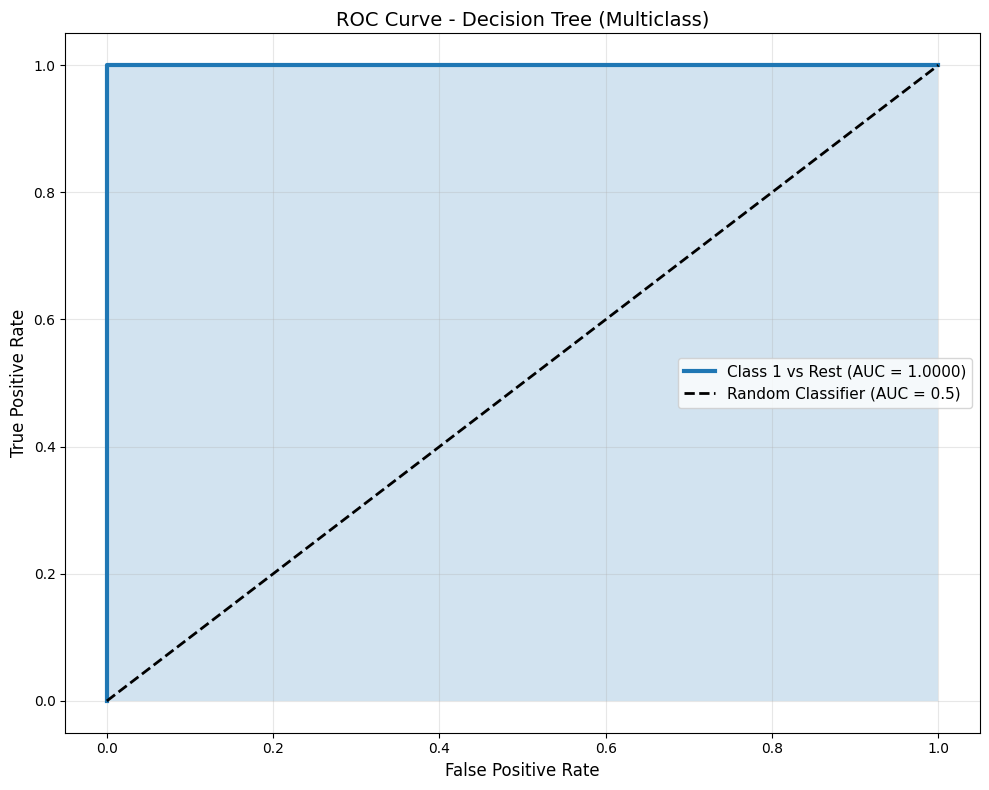


📊 ROC-AUC Score (Class 1): 1.0000


In [76]:
y_pred_proba = dt_2d.predict_proba(X_test_2d)

class_idx = 1 
fpr, tpr, thresholds = roc_curve(y_test == class_idx, y_pred_proba[:, class_idx])
roc_auc = roc_auc_score(y_test == class_idx, y_pred_proba[:, class_idx])

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=3, label=f'Class {class_idx} vs Rest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Decision Tree (Multiclass)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 ROC-AUC Score (Class {class_idx}): {roc_auc:.4f}")

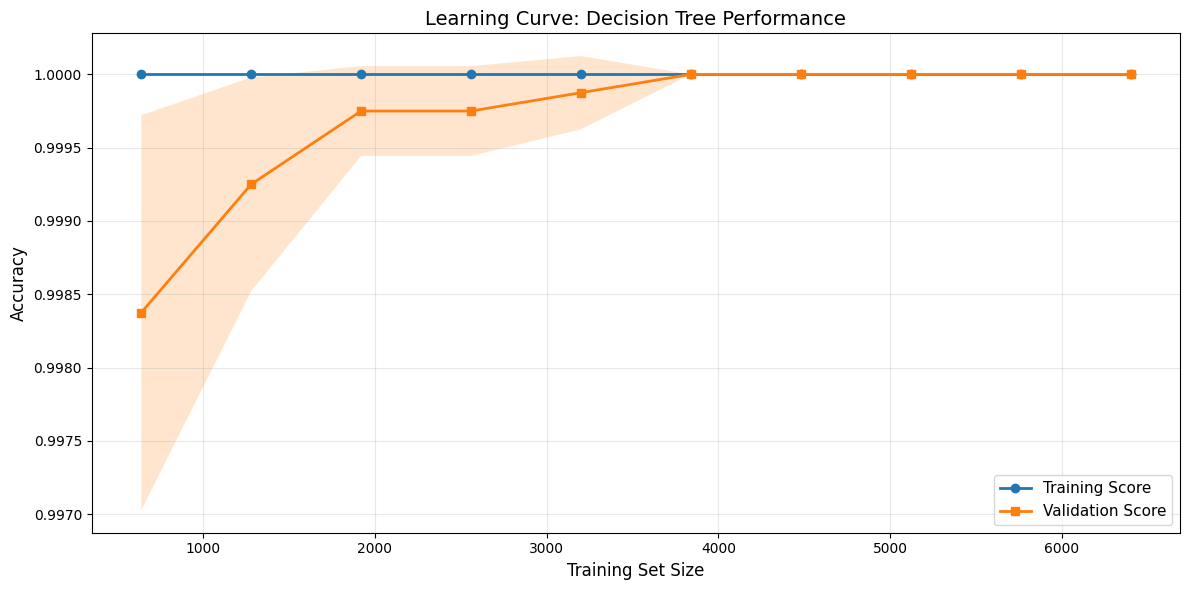


 Learning Curve Analysis:
Training Score (full data):   1.0000
Validation Score (full data): 1.0000
Gap: 0.0000


In [77]:
train_sizes, train_scores, val_scores = learning_curve(
    dt_2d,
    X_train_2d,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o', linewidth=2)
plt.plot(train_sizes, val_mean, label='Validation Score', marker='s', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Learning Curve: Decision Tree Performance', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Learning Curve Analysis:")
print(f"Training Score (full data):   {train_mean[-1]:.4f}")
print(f"Validation Score (full data): {val_mean[-1]:.4f}")
print(f"Gap: {train_mean[-1] - val_mean[-1]:.4f}")


 Testing Model Stability (50 different random initializations)...


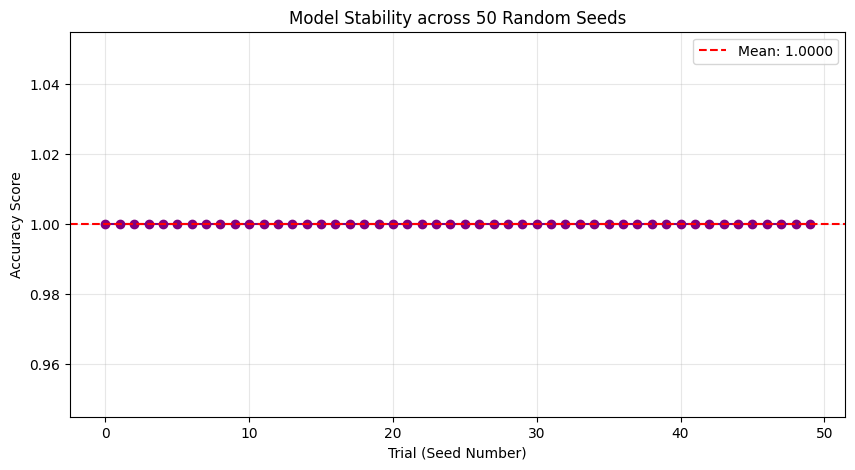


 Stability Analysis:
Mean Accuracy: 1.0000
Std Deviation: 0.0000
Min Accuracy:  1.0000
Max Accuracy:  1.0000


In [78]:
n_trials = 50
accuracies = []

print("\n Testing Model Stability (50 different random initializations)...")

for seed in range(n_trials):
    dt_temp = DecisionTreeClassifier(
        max_depth=10, 
        random_state=seed
    )
    dt_temp.fit(X_train_2d, y_train)
    accuracies.append(dt_temp.score(X_test_2d, y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(n_trials), accuracies, marker='o', linestyle='-', color='purple')
plt.axhline(np.mean(accuracies), color='red', linestyle='--', label=f'Mean: {np.mean(accuracies):.4f}')
plt.xlabel('Trial (Seed Number)')
plt.ylabel('Accuracy Score')
plt.title('Model Stability across 50 Random Seeds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n Stability Analysis:")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}")
print(f"Std Deviation: {np.std(accuracies):.4f}")
print(f"Min Accuracy:  {min(accuracies):.4f}")
print(f"Max Accuracy:  {max(accuracies):.4f}")

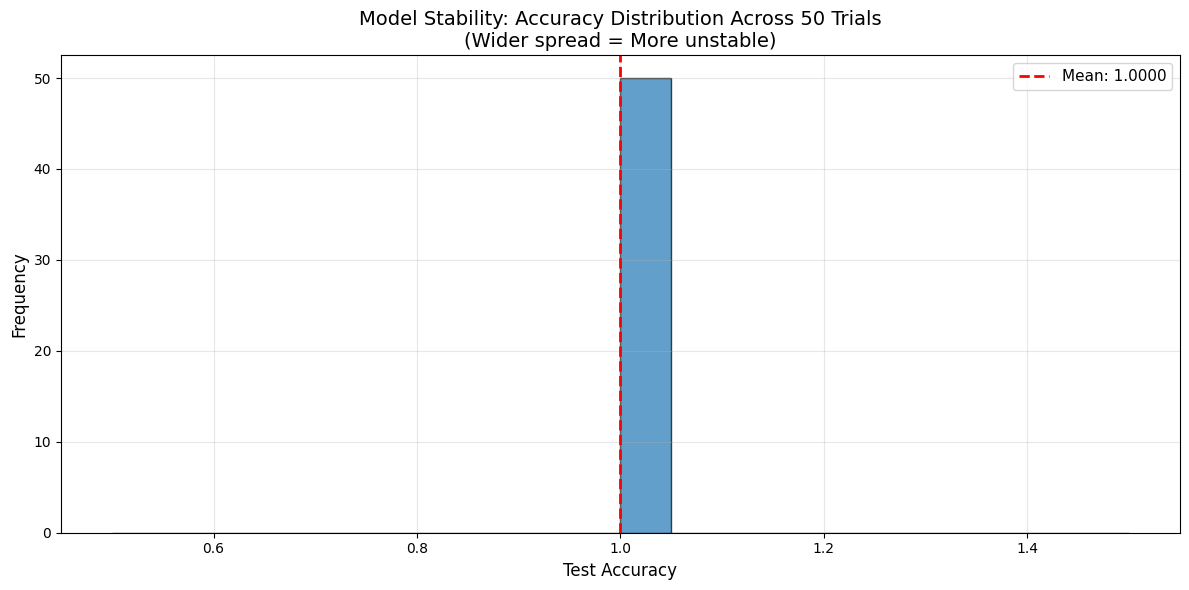


 Stability Analysis:
Mean Accuracy: 1.0000
Std Dev:       0.0000
Min:           1.0000
Max:           1.0000
Range:         0.0000

 Decision trees have HIGH VARIANCE (sensitive to data changes)
Solution: Use ensemble methods (Random Forest, Gradient Boosting)


In [79]:
plt.figure(figsize=(12, 6))
plt.hist(accuracies, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=np.mean(accuracies), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(accuracies):.4f}')

plt.xlabel('Test Accuracy', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Model Stability: Accuracy Distribution Across 50 Trials\n(Wider spread = More unstable)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Stability Analysis:")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}")
print(f"Std Dev:       {np.std(accuracies):.4f}")
print(f"Min:           {np.min(accuracies):.4f}")
print(f"Max:           {np.max(accuracies):.4f}")
print(f"Range:         {np.max(accuracies) - np.min(accuracies):.4f}")

print("\n Decision trees have HIGH VARIANCE (sensitive to data changes)")
print("Solution: Use ensemble methods (Random Forest, Gradient Boosting)")

In [80]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

log_reg = LogisticRegression(random_state=42, max_iter=10000)
log_reg.fit(X_train_scaled, y_train)

comparison = pd.DataFrame({
    'Model': ['Decision Tree (Depth 10)', 'Logistic Regression'],
    'Test Accuracy': [
        dt_2d.score(X_test_2d, y_test),
        log_reg.score(X_test_scaled, y_test)
    ],
    'F1 Score': [
        f1_score(y_test, dt_2d.predict(X_test_2d), average='weighted'),
        f1_score(y_test, log_reg.predict(X_test_scaled), average='weighted')
    ],
    'Interpretability': ['High (visual)', 'High (coefficients)'],
    'Feature Scaling': ['Not needed', 'Required'],
    'Decision Boundary': ['Non-linear', 'Linear']
})

print(comparison.to_string(index=False))

                   Model  Test Accuracy  F1 Score    Interpretability Feature Scaling Decision Boundary
Decision Tree (Depth 10)         1.0000    1.0000       High (visual)      Not needed        Non-linear
     Logistic Regression         0.9965    0.9965 High (coefficients)        Required            Linear


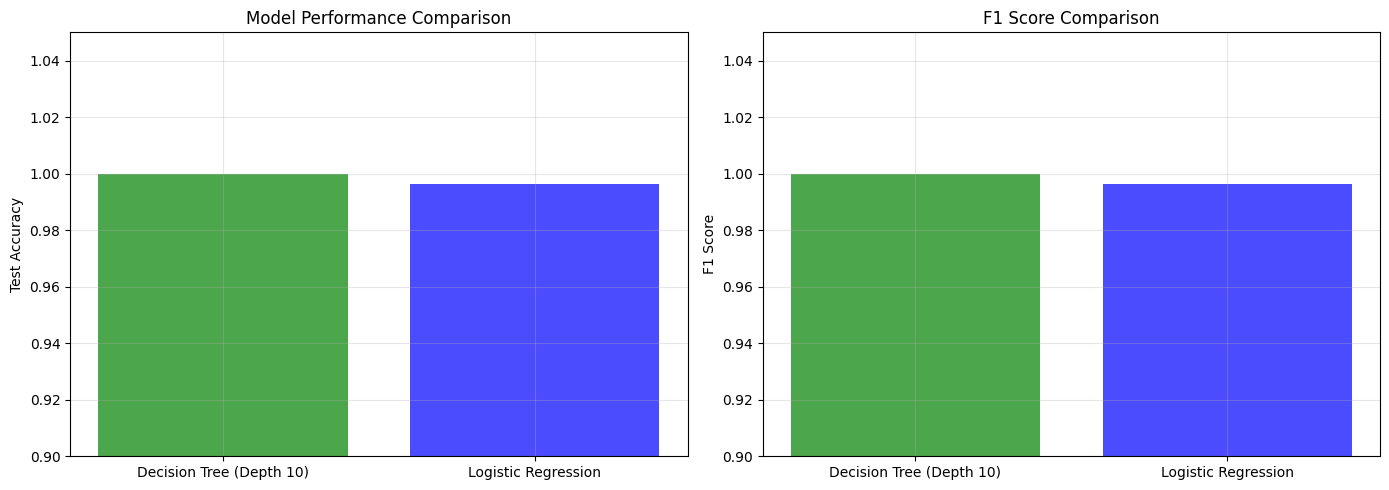

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison['Model']

axes[0].bar(models, comparison['Test Accuracy'], alpha=0.7, color=['green', 'blue'])
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylim([0.9, 1.05])
axes[0].grid(True, alpha=0.3)

axes[1].bar(models, comparison['F1 Score'], alpha=0.7, color=['green', 'blue'])
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score Comparison')
axes[1].set_ylim([0.9, 1.05])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
from sklearn.pipeline import Pipeline
production_pipeline = Pipeline([
    ('classifier', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=1,
        criterion='gini',
        random_state=42
    ))
])

production_pipeline.fit(X_train_2d, y_train)

y_pred_pipeline = production_pipeline.predict(X_test_2d)
pipeline_accuracy = accuracy_score(y_test, y_pred_pipeline)

print(" Production Pipeline Performance:")
print(f"Accuracy: {pipeline_accuracy:.4f}")

 Production Pipeline Performance:
Accuracy: 1.0000


In [83]:
import joblib

joblib.dump(production_pipeline, 'best_decision_tree_pipeline.pkl')
print("\n Pipeline saved as 'best_decision_tree_pipeline.pkl'")

loaded_pipeline = joblib.load('best_decision_tree_pipeline.pkl')
test_pred = loaded_pipeline.predict(X_test_2d[:3])

print("\n Testing Loaded Pipeline:")
print(f"Predictions: {test_pred}")
print(f"Actual Labels: {y_test[:3]}")
print(" Pipeline works correctly!")


 Pipeline saved as 'best_decision_tree_pipeline.pkl'

 Testing Loaded Pipeline:
Predictions: [0 1 0]
Actual Labels: 6252    0
4684    1
1731    0
Name: Emission Level, dtype: int64
 Pipeline works correctly!
